# Reproducing results on the Sage paper

## Packages

In [1]:
! pip uninstall sage -y
! pip install -e ../

Found existing installation: sage 0.0.1
Uninstalling sage-0.0.1:
  Successfully uninstalled sage-0.0.1
Obtaining file:///home/nnarenraju/Research/sage
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sage (pyproject.toml) ... done
  Created wheel for sage: filename=sage-0.0.1-0.editable-py3-none-any.whl size=15108 sha256=c223c2a4a860b24fde37acf25791b24aa3842852b4139c7d599e0ffbb82f4a37
  Stored in directory: /tmp/pip-ephem-wheel-cache-i_16gxqz/wheels/9b/47/cf/bfd99e705866b88810d9db84a85969530a2783f51228948a36
Successfully built sage


In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import h5py
import time
import torch
import numpy as np

import matplotlib.pyplot as plt

import lal
import lalsimulation as lalsim

In [3]:
def time_it(func, args, ntries=1000):
    start = time.time()
    for _ in range(ntries):
        func(args)
    time_taken = (time.time() - start)/ntries
    return time_taken

## Get Segments for Downloading Real Noise 

In [ ]:
from sage.data.primer import TimelineQuery, get_all_detnames, get_all_runnames

In [ ]:
print(get_all_detnames())
print(get_all_runnames())

In [ ]:
tq = TimelineQuery(detector=["H1", "L1", "V1"], 
                   observing_run=["O3a",],
                   start = 1238166018,
                   end = 1238176018,
                   auto_clean_empty_timelines=True)
                                
tq.download_segments()

In [ ]:
tq.prune_segments(
    rm_short_segments = True,
    rm_min_duration = 22.0,
    rm_allevents = True,
    rm_window_length = 30,
)

In [ ]:
tq.timeline

## Download Segments from GWOSC

In [ ]:
from sage.data.primer import DataReleaseDownloader

In [ ]:
drd = DataReleaseDownloader(
    segments_metadata=tq.timeline,
    save_parent_dir="./",
    noise_low_freq_cutoff = 15.0,
    minimum_segment_duration = 22.0,
    corrupt_trim_length = 0.2,
    max_download_retries = 15,
    retry_delay = 0.5,
    num_workers = 4,
    make_monolithic_file = True,
    sample_rate = 2048.0,
)

drd.download()

In [ ]:
foo = h5py.File('./data_release/data_L1_O3a.h5', 'r')
print(list(foo.keys()))

In [ ]:
foo['segments'].keys()

In [ ]:
# TODO: Find out why this is slightly smaller than expected
num = np.array(foo['segments/00000']).shape[0] + np.array(foo['segments/00001']).shape[0]
print((num+0)/2048.)

In [ ]:
foo['segments/00000'].attrs.keys()

## Get Noise PSD Estimates from Real Noise

In [ ]:
from sage.data.noise import GenerateRealNoise
from sage.data.primer import EstimatePSD
from sage.dsp.welch import WelchPSD
from sage.data.primer import NoBlackout, HardRatioBlackout

In [ ]:
noise_gen = GenerateRealNoise("./data_release/data_L1_O3a.h5")
noise_gen(2048)

In [ ]:
# Generating 20s of noise (on average over 10_000 tries takes 0.0019665 seconds)
# Generating 13s of noise (on average over 10_000 tries takes 0.0014012 seconds)
# Multiply this time by the number of detectors we will input into Sage
time_it(noise_gen, args=(int(13.*2048.),), ntries=10_000)

In [ ]:
class cfg:
    export_dir = "./export_dir"

class data_cfg:
    data_dir = "./data_dir"
    sample_rate = 2048.
    sample_length_in_seconds = 15

epsd = EstimatePSD(
    detector = 'H1',
    num_samples = 10,
    psd_method=WelchPSD(sample_rate=2048., nperseg_in_seconds=4),
    blackout_policy=NoBlackout(),
    store_raw_psds = True,
)

fiducial_psd, freqs = epsd(
    noise_source=noise_gen, 
    cfg=cfg(), 
    data_cfg=data_cfg()
)

plt.plot(freqs, fiducial_psd)
plt.xscale('log')
plt.yscale('log')
plt.xlim(15, 1024)
plt.show()

In [ ]:
class cfg:
    export_dir = "./export_dir"

class data_cfg:
    data_dir = "./data_dir"
    sample_rate = 2048.
    sample_length_in_seconds = 15

epsd = EstimatePSD(
    detector = 'H1',
    num_samples = 10,
    psd_method=WelchPSD(sample_rate=2048., nperseg_in_seconds=4),
    blackout_policy=HardRatioBlackout(4.0),
    store_raw_psds = True,
)

fiducial_psd, freqs = epsd(
    noise_source=noise_gen, 
    cfg=cfg(), 
    data_cfg=data_cfg()
)

plt.plot(freqs, fiducial_psd)
plt.xscale('log')
plt.yscale('log')
plt.xlim(15, 1024)
plt.ylim(1e-49, 1e-39)
plt.show()

## Sage fully vectorised signal generation on torch.compile (IMRPhenomD)

In [4]:
from sage.data.waveform import IMRPhenomD as imr
from sage.data.waveform import project

In [5]:
IMRphenom = 'IMRPhenomD'

m1_msun = 30.0 # In solar masses
m2_msun = 30.0
chi1 = 0.99
chi2 = 0.99
tc = 0.0 # Time of coalescence in seconds
phic = 0.5
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.5 # Inclination Angle
polarization_angle = 0.0 # Polarization angle
ra = 0.12
dec = 0.2

params = torch.tensor(
    [m1_msun, m2_msun, chi1, chi2, dist_mpc, tc, phic, inclination, polarization_angle, ra, dec],
    device='cuda:0',
    dtype=torch.float64
)

batch_size = 500
params_batch = params.unsqueeze(0).expand(batch_size, -1).clone()  # shape: (10, 9)

In [6]:
# Generate the frequency grid
f_l = 20.
f_u = 2048.
del_f = 1./20.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)
f = f.unsqueeze(0).expand(batch_size, -1).clone()

f_ref = torch.tensor(f_l, device='cuda:0', dtype=torch.float64)
f_ref = f_ref.unsqueeze(0).expand(batch_size, -1).clone()

In [7]:
phd = imr.IMRPhenomD(f, f_ref)

In [8]:
## With compile we take 0.0005 seconds for 500 waveforms (20 seconds at 2048 Hz)
start = time.time()
hp_sage, hc_sage = phd(params_batch, reproduce_lal=True)
print(f"Time taken to produce 500 IMRPhenomD waveforms = {time.time() - start}")

Time taken to produce 500 IMRPhenomD waveforms = 0.3317246437072754


Requested tc = 0.0 s, observed tc = 19.995 s


(81850.0, 81950.0)

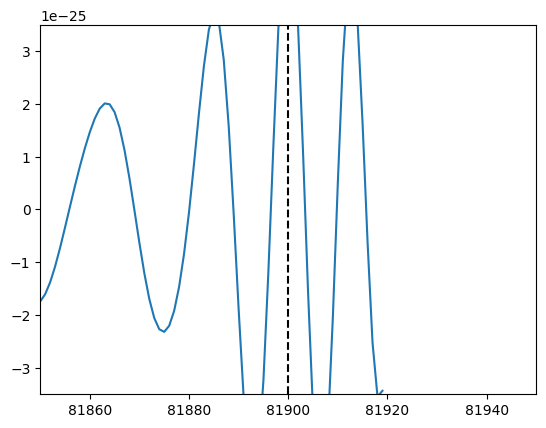

In [9]:
t_peak = torch.argmax(torch.abs(torch.fft.irfft(hp_sage[0])), dim=-1)
t_peak = t_peak.detach().cpu().numpy()
print(f"Requested tc = {params[5]} s, observed tc = {round(t_peak/4096., 3)} s")

plt.plot(np.fft.irfft(hp_sage[0].detach().cpu().numpy()))
plt.vlines(t_peak, -3.5e-25, 3.5e-25, linestyle="--", color='k')
plt.ylim(-3.5e-25, 3.5e-25)
plt.xlim(t_peak-50, t_peak+50)

In [ ]:
## With compile we take 0.000325 seconds PER waveform 20 seconds at 2048 Hz (1000 tries over batches of 500)
out = time_it(phd, (params_batch), ntries=1000)
print('Time taken to produce 1 waveform with PyTorch (without compile) = {} seconds'.format(round(out/500.,10)))

IT'S ALIVE!!!

With torch.compile we take about 0.00032 seconds per waveform. So about 3124 waveforms per second. Each waveform is 20 seconds long at a sampling frequency of 2048 Hz. This is pretty good and should be more than fast enough for training Sage.

In [10]:
pwave = project.ProjectWave(detector_names = ('H1', 'L1', 'V1'), device='cuda:0')

In [11]:
f_l = 0.
f_u = 2048.
del_f = 1./20.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)

In [14]:
start = time.time()
out = pwave.constant_project(hp_sage, hc_sage, f, ra=params_batch[:,-2], dec=params_batch[:,-1], polarization=params_batch[:,-3])
print(time.time()-start)

0.0012238025665283203


### Comparing fully vectorised Sage to LAL for IMRPhenomD

In [10]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomD")
m1_msun = 30.0 # In solar masses
m2_msun = 30.0
chi1 = 0.99
chi2 = 0.99
tc = 0.0 # Time of coalescence in seconds
phic = 0.5
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.5 # Inclination Angle
m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

# Params for freq domain waveform
f_min = 20.0
f_max = 2048.0
f_ref = f_min
df = 1.0/20.0
sample_length_in_s = 1./df

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            0., 0., chi1,
                                            0., 0., chi2,
                                            distance, inclination,
                                            phic, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)
hp_lalsim = hp.data.data
hc_lalsim = hc.data.data

/home/nnarenraju/software/envs/refactor/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nnarenraju/software/envs/refactor/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


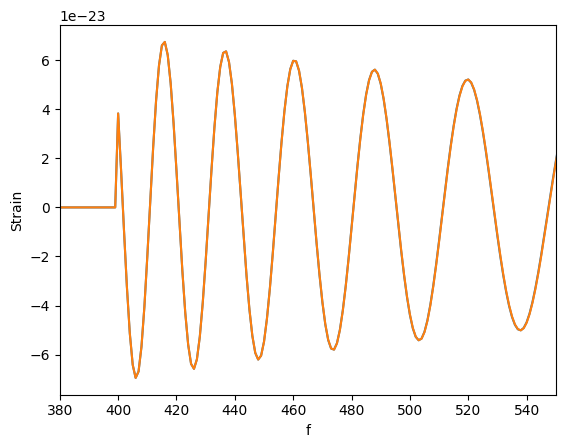

In [11]:
plt.plot(hp_lalsim)
plt.plot(hp_sage[0].detach().cpu().numpy())
plt.xlim(380, 550)
plt.xlabel('f')
plt.ylabel('Strain')
plt.show()

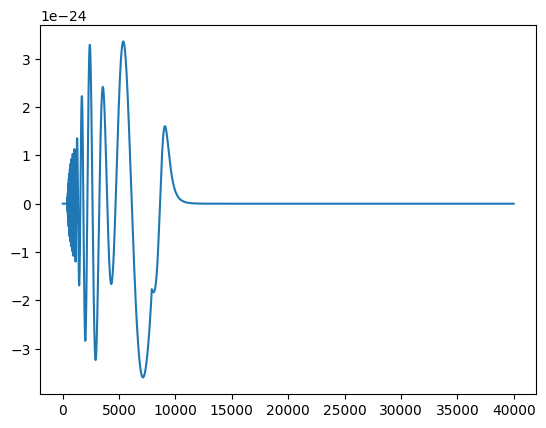

In [12]:
plt.plot(hc_sage[0].detach().cpu().numpy()[:40_000] - hc_lalsim[:40_000])

LAL might have extra zeroes padded to get the length to the next power of two. So a requested length of 40961 (20 seconds at 2048 Hz + 1) will produce 65537 (this is 2**16 + 1). The extra +1 is due to accounting for the DC componenet of 0*df.

## Sage fully vectorised signal generation on torch.compile (IMRPhenomPv2)

In [4]:
from sage.data.waveform import IMRPhenomPv2 as pv2

In [19]:
IMRphenom = 'IMRPhenomPv2'

m1 = 20.0
m2 = 19.0
s1x = 0.5
s1y = 0.5
s1z = 0.5
s2x = 0.5
s2y = 0.5
s2z = 0.5
dist_mpc = 440.0
tc = 0.0
phic = 0.5
inclination = 0.2
polarization_angle = 0
ra = 0.12
dec = 0.2

params = torch.tensor(
    [m1, m2, s1x, s1y, s1z, s2x, s2y, s2z, dist_mpc, tc, phic, inclination, polarization_angle, ra, dec],
    device='cuda:0',
    dtype=torch.float64
)

batch_size = 1
params_batch = params.unsqueeze(0).expand(batch_size, -1).clone()

In [20]:
# Generate the frequency grid
f_l = 20.
f_u = 2048.
del_f = 1./20.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)
f = f.unsqueeze(0).expand(batch_size, -1).clone()

f_ref = torch.tensor(f_l, device='cuda:0', dtype=torch.float64)
f_ref = f_ref.unsqueeze(0).expand(batch_size, -1).clone()

In [21]:
php = pv2.IMRPhenomPv2(f, f_ref)

In [22]:
hp_sage, hc_sage = php(params_batch)

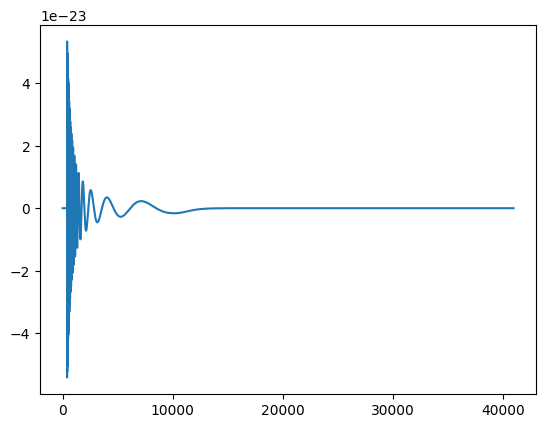

In [23]:
plt.plot(hp_sage[0].detach().cpu().numpy())

### Comparing fully vectorised Sage to LAL for IMRPhenomPv2

In [24]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomPv2")
m1_msun = 20.0 # In solar masses
m2_msun = 19.0
chi1 = 0.5
chi2 = 0.5
tc = 0.0 # Time of coalescence in seconds
phic = 0.5
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.2 # Inclination Angle
m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

# Params for freq domain waveform
f_min = 20.0
f_max = 2048.0
f_ref = f_min
df = 1./20.
sample_length_in_s = 1./df

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            0.5, 0.5, chi1,
                                            0.5, 0.5, chi2,
                                            distance, inclination,
                                            phic, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)
hp_lalsim = hp.data.data
hc_lalsim = hc.data.data

(350.0, 1000.0)

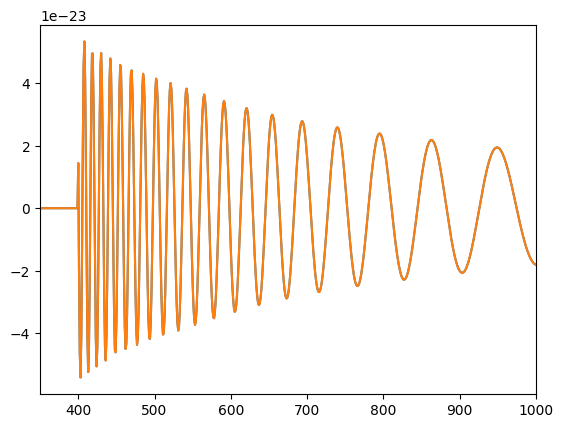

In [25]:
plt.plot(hp_sage[0].detach().cpu().numpy())
plt.plot(hp_lalsim)
plt.xlim(350, 1000)

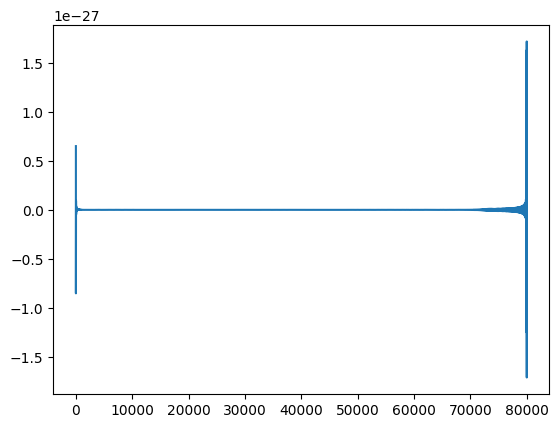

In [26]:
plt.plot(np.fft.irfft(hp_sage[0].detach().cpu().numpy()[:40_000]) - np.fft.irfft(hp_lalsim[:40_000]))

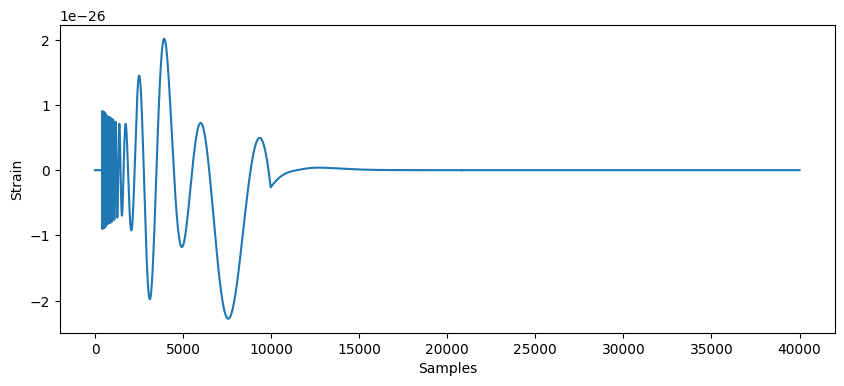

In [27]:
plt.figure(figsize=(10.0, 4.0))
plt.plot(hp_lalsim[:40_000] - hp_sage[0].detach().cpu().numpy()[:40_000])
plt.xlabel('Samples')
plt.ylabel('Strain')
plt.show()